#  Demonstrate the voltage dependence of permeation through N-type and L-type Ca$_V$ channels as a model

## Question(s)

Can the mechanics of calcium channels be repricated in a toy neuron model? 
Can a computational model reproduce the dose-response behavior of $Ca_V$ channels to simulate the effects of mutations and drugs?

## Background

Buraei, Z., Lee, H. K., & Elmslie, K. S. (2015). Single channel measurements demonstrate the voltage dependence of permeation through N-type and L-type CaV channels. Channels, 9(1), 50–55. https://doi.org/10.4161/19336950.2014.991606

Hess, P., Tsien, R. Mechanism of ion permeation through calcium channels. Nature 309, 453–456 (1984). https://doi.org/10.1038/309453a0

## Ingredients

In [5]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import time

In [6]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
# use NMA plot style
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")
my_layout = widgets.Layout()

In [7]:
# @title Plotting Functions

def example_plot_myCC():
  pars = default_pars(T=50000, dt=.1)

  c = np.arange(10) * 0.1
  r12 = np.zeros(10)
  for i in range(10):
    I1gL, I2gL = correlate_input(pars, mu=20.0, sig=7.5, c=c[i])
    r12[i] = my_CC(I1gL, I2gL)

  plt.figure()
  plt.plot(c, r12, 'bo', alpha=0.7, label='Simulation', zorder=2)
  plt.plot([-0.05, 0.95], [-0.05, 0.95], 'k--', label='y=x',
           dashes=(2, 2), zorder=1)
  plt.xlabel('True CC')
  plt.ylabel('Sample CC')
  plt.legend(loc='best')
  plt.show()


def my_raster_Poisson(range_t, spike_train, n):
  """
  Ffunction generates and plots the raster of the Poisson spike train

  Args:
    range_t     : time sequence
    spike_train : binary spike trains, with shape (N, Lt)
    n           : number of Poisson trains plot

  Returns:
    Raster plot of the spike train
  """

  # find the number of all the spike trains
  N = spike_train.shape[0]

  # n should smaller than N:
  if n > N:
    print('The number n exceeds the size of spike trains')
    print('The number n is set to be the size of spike trains')
    n = N

  # plot rater
  plt.figure()
  i = 0
  while i < n:
    if spike_train[i, :].sum() > 0.:
      t_sp = range_t[spike_train[i, :] > 0.5]  # spike times
      plt.plot(t_sp, i * np.ones(len(t_sp)), 'k|', ms=10, markeredgewidth=2)
    i += 1
  plt.xlim([range_t[0], range_t[-1]])
  plt.ylim([-0.5, n + 0.5])
  plt.xlabel('Time (ms)', fontsize=12)
  plt.ylabel('Neuron ID', fontsize=12)
  plt.show()

def plot_c_r_LIF(c, r, mycolor, mylabel):
  z = np.polyfit(c, r, deg=1)
  c_range = np.array([c.min() - 0.05, c.max() + 0.05])
  plt.plot(c, r, 'o', color=mycolor, alpha=0.7, label=mylabel, zorder=2)
  plt.plot(c_range, z[0] * c_range + z[1], color=mycolor, zorder=1)

In [149]:
# @title Helper Functions
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = -55     # spike threshold [mV]
  pars['V_reset'] = -75.  # reset potential [mV]
  pars['tau_m'] = 10.     # membrane time constant [ms]
  pars['g_L'] = 10.       # leak conductance [nS]
  pars['V_init'] = -75.   # initial potential [mV]
  pars['V_L'] = -75.      # leak reversal potential [mV]
  pars['tref'] = 2.0       # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 400. # Total duration of simulation [ms]
  pars['dt'] = .1  # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized
                                                         # time points [ms]
  return pars


def run_LIF(pars, Iinj):
  """
  Simulate the LIF dynamics with external input current

  Args:
    pars       : parameter dictionary
    Iinj       : input current [pA]. The injected current here can be a value or an array

  Returns:
    rec_spikes : spike times
    rec_v      : mebrane potential
  """

  # Set parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, V_L = pars['V_init'], pars['V_L']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size
  tref = pars['tref']

  # Initialize voltage and current
  v = np.zeros(Lt)
  v[0] = V_init
  Iinj = Iinj * np.ones(Lt)
  tr = 0.

  # simulate the LIF dynamics
  rec_spikes = []   # record spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    # calculate the increment of the membrane potential
    dv = (-(v[it] - V_L) + Iinj[it] / g_L) * (dt / tau_m)

    # update the membrane potential
    v[it + 1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes

## Mathematically-defined Hypothesis


We hypothesize that the voltage-dependent decrease in N-type calcium channel affinity modulates Ca²⁺ influx during depolarization. Specifically, at membrane potentials below 0 mV, channel affinity remains high, allowing normal calcium permeation. As voltage rises above 0 mV, channel affinity decreases in a voltage-dependent manner, which we model as a linear function of membrane potential:

Literature suggests the effect starts > 0 mV, which will defined as our baseline as V$_0$:


\begin{equation}
\text{EC50} = 
\begin{cases}
\text{EC50}_{\text{rest}}, & V \le 0 \\
\text{EC50}_{\text{rest}} + k \cdot (V - V_0), & V > 0,
\end{cases}
\end{equation}


where k is a free parameter controlling the slope of affinity decrease. We further hypothesize that this voltage-dependent modulation acts to slow Ca²⁺ influx during the plateau phase of the action potential, preventing excessive calcium entry while still allowing functional signaling. A computational model incorporating these dynamics should replicate the experimental observations of N-channel permeation, and could be extended to simulate L-channel behavior in parallel.



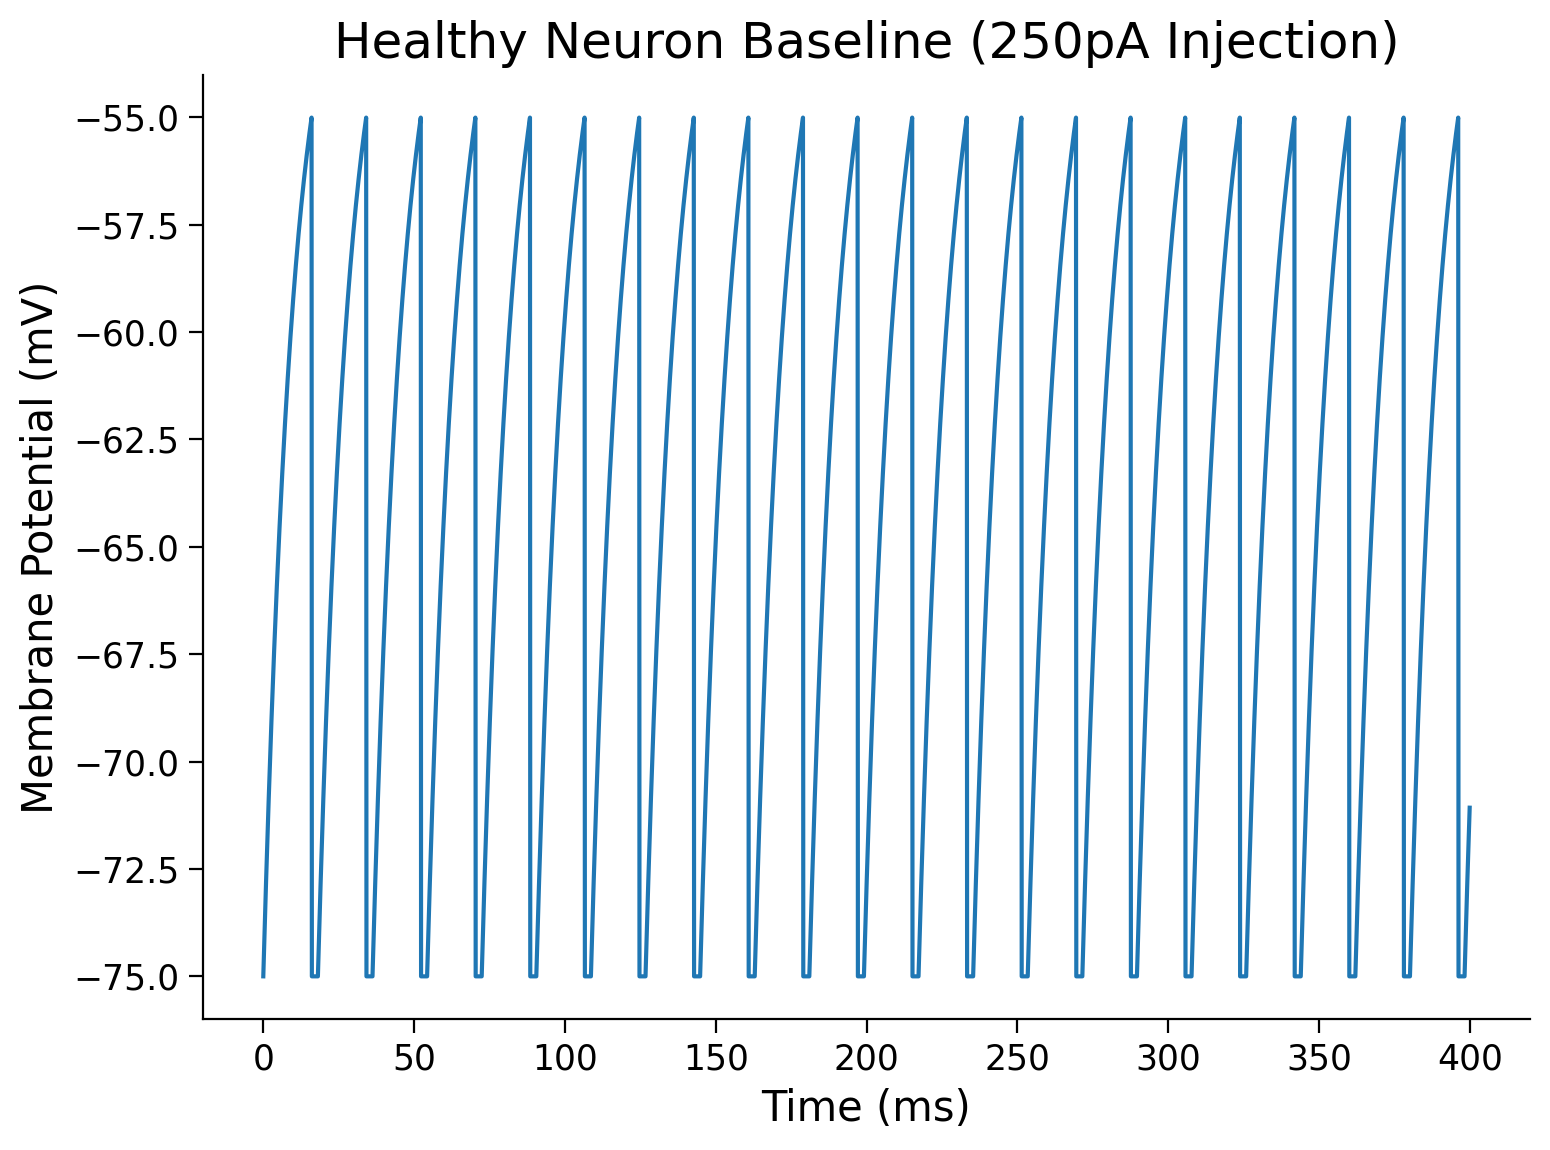

In [146]:
# HEALTHY NEURON
pars = default_pars()
current_inj = 250
v, spikes = run_LIF(pars, Iinj=current_inj) # Inject pA of current
plt.plot(pars['range_t'], v)
plt.title(f'Healthy Neuron Baseline ({current_inj}pA Injection)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.show()

In [173]:
def run_CaV_model(pars, Iinj, Conc=10.0):
  """
  Simulate the LIF dynamics with external input current

  Args:
    pars       : parameter dictionary
    Iinj       : input current [pA]. The injected current here can be a value or an array

  Returns:
    rec_spikes : spike times
    rec_v      : mebrane potential
  """

    
  V_ca = 120.0  # Calcium reversal potential (mV)
  g_ca = 2.0    # Strength of Calcium channels
  # Conc = 10.0   # Ba2+ concentration (mM) from Buraei Fig 1
  EC50_rest = 13.0
  k = 1.2

  # Set parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, V_L = pars['V_init'], pars['V_L']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size
  tref = pars['tref']

  # Initialize voltage and current
  v = np.zeros(Lt)
  v[0] = V_init
  Iinj = Iinj * np.ones(Lt)
  tr = 0.

  # simulate the LIF dynamics
  rec_spikes = []   # record spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    if v[it] <= 0:
        current_ec50 = EC50_rest
    else:
        current_ec50 = EC50_rest + k * v[it]

    m = Conc / (Conc + current_ec50)
    if it == 2000: # Pick any time point in the middle
            print(f"Open Probability (m) is: {m}")

    # calculate the increment of the membrane potential
    dv = ((-(v[it] - V_L) + Iinj[it] / g_L) - (g_ca * m * (v[it] - V_ca) / g_L)) * (dt / tau_m)

    # update the membrane potential
    v[it + 1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes

Open Probability (m) is: 0.43478260869565216


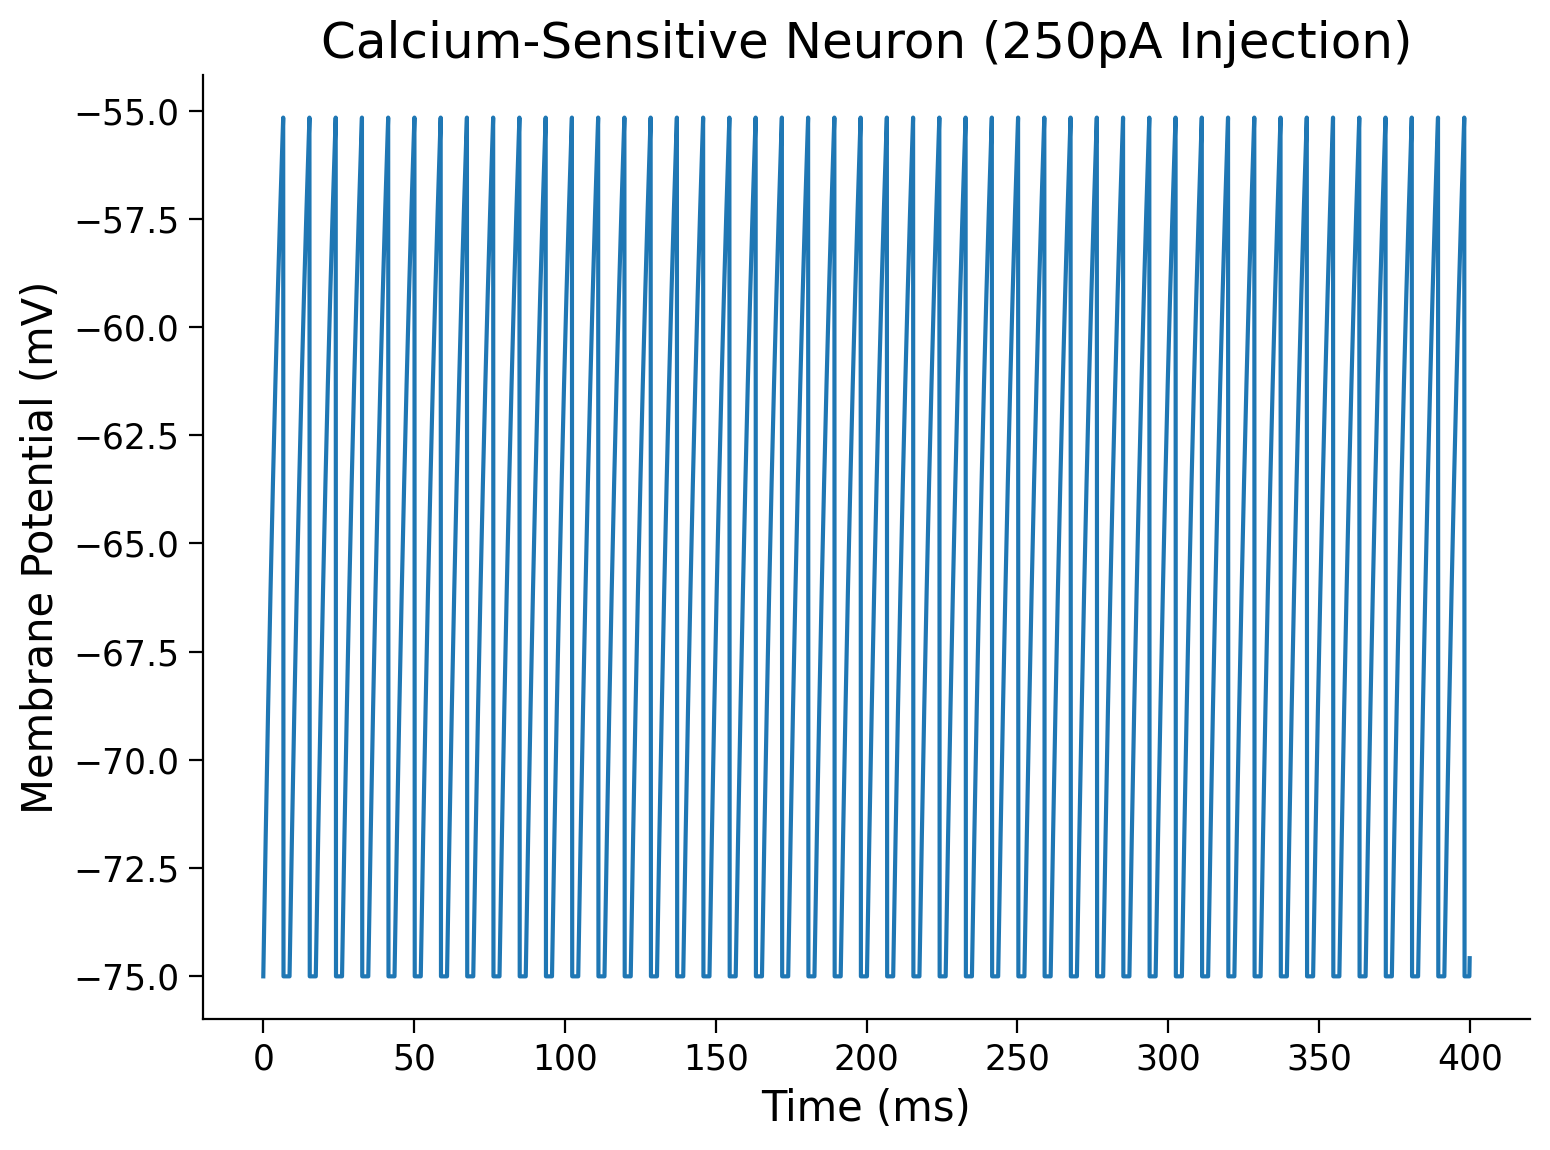

In [175]:
pars = default_pars()
v, spikes = run_CaV_model(pars, Iinj=current_inj) # Inject pA of current
plt.plot(pars['range_t'], v)
plt.title(f'Calcium-Sensitive Neuron ({current_inj}pA Injection)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.show()

Open Probability (m) is: 0.07142857142857142
Open Probability (m) is: 0.1875
Open Probability (m) is: 0.43478260869565216
Open Probability (m) is: 0.6976744186046512
Open Probability (m) is: 0.8849557522123894


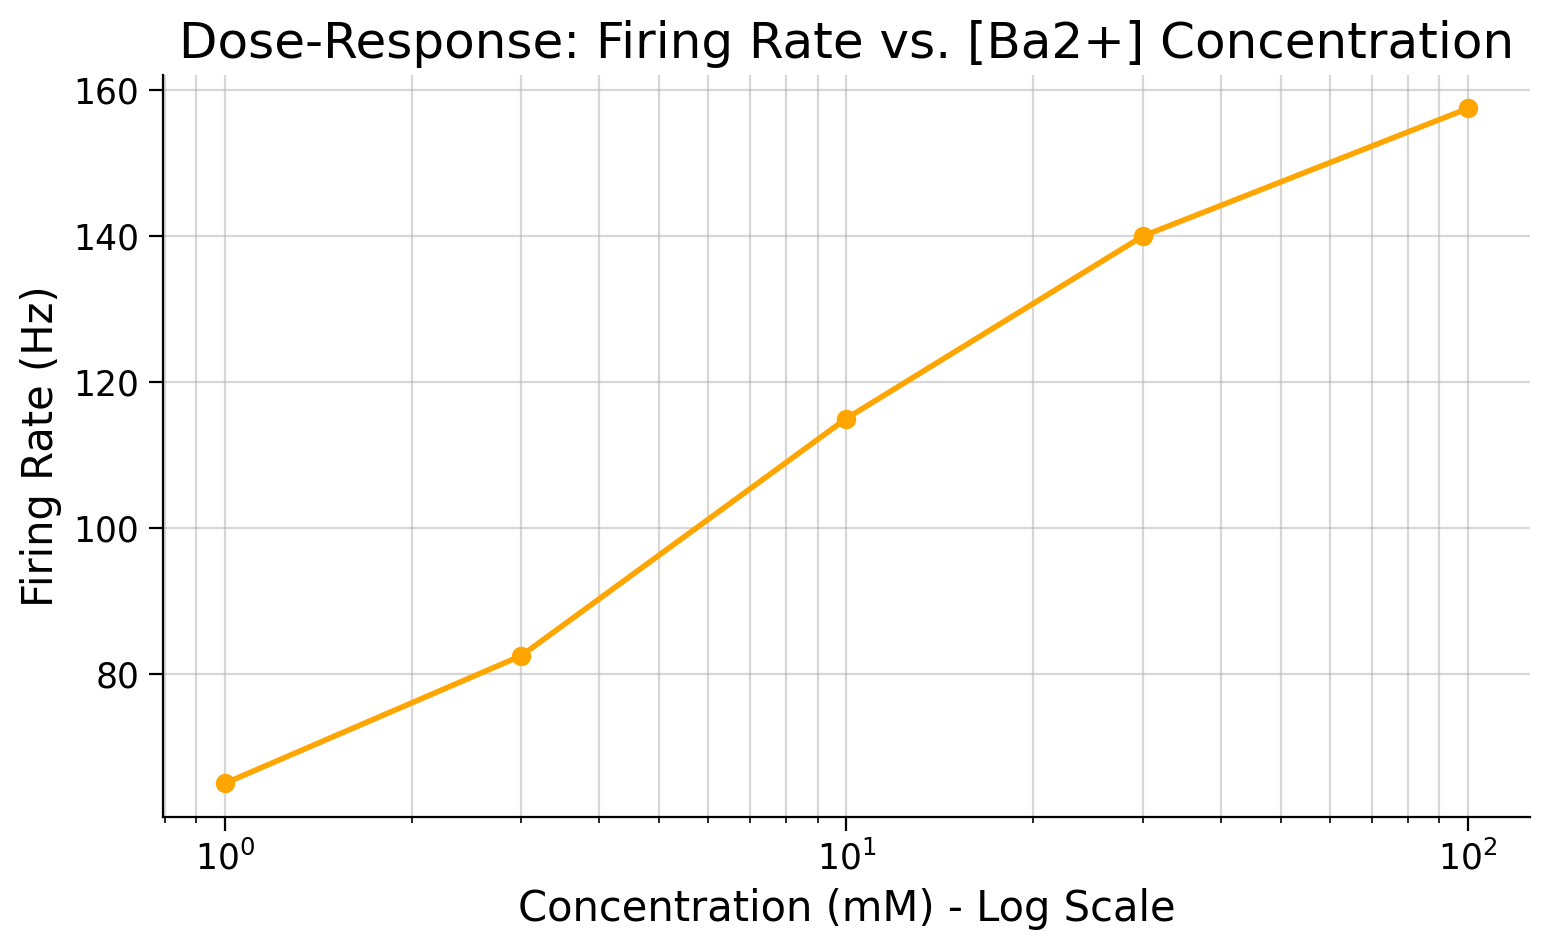

In [172]:
# Define a range of concentrations to test (from 1mM to 100mM)
concentrations = [1, 3, 10, 30, 100]
firing_rates = []

for c in concentrations:
    # We pass 'Conc' as an extra parameter
    # Note: You'll need to update your run_CaV_model to accept Conc or set it globally
    v_test, spikes_test = run_CaV_model(pars, Iinj=250, Conc=c)
    
    # Calculate firing rate (Hz): (Number of spikes / Total Time in ms) * 1000
    rate = (len(spikes_test) / pars['T']) * 1000
    firing_rates.append(rate)

# Plot the Result
plt.figure(figsize=(8, 5))
plt.semilogx(concentrations, firing_rates, 'o-', color='orange', linewidth=2)
plt.title('Dose-Response: Firing Rate vs. [Ba2+] Concentration')
plt.xlabel('Concentration (mM) - Log Scale')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

The Dose-Response loop is working! The output shows that the Open Probability ($m$) is now changing based on the concentration ($1\text{ mM}$ to $100\text{ mM}$), and the firing rate curve has the classic logarithmic "S-shape."

In [176]:
# @title Helper Functions
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = 30    # spike threshold [mV]
  pars['V_reset'] = -65.  # reset potential [mV]
  pars['tau_m'] = 10.     # membrane time constant [ms]
  pars['g_L'] = 10.       # leak conductance [nS]
  pars['V_init'] = -75.   # initial potential [mV]
  pars['V_L'] = -75.      # leak reversal potential [mV]
  pars['tref'] = 2.0       # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 400. # Total duration of simulation [ms]
  pars['dt'] = .1  # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized
                                                         # time points [ms]
  return pars


def run_LIF(pars, Iinj):
  """
  Simulate the LIF dynamics with external input current

  Args:
    pars       : parameter dictionary
    Iinj       : input current [pA]. The injected current here can be a value or an array

  Returns:
    rec_spikes : spike times
    rec_v      : mebrane potential
  """

  # Set parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, V_L = pars['V_init'], pars['V_L']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size
  tref = pars['tref']

  # Initialize voltage and current
  v = np.zeros(Lt)
  v[0] = V_init
  Iinj = Iinj * np.ones(Lt)
  tr = 0.

  # simulate the LIF dynamics
  rec_spikes = []   # record spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    # calculate the increment of the membrane potential
    dv = (-(v[it] - V_L) + Iinj[it] / g_L) * (dt / tau_m)

    # update the membrane potential
    v[it + 1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes

Open Probability (m) is: 0.43478260869565216


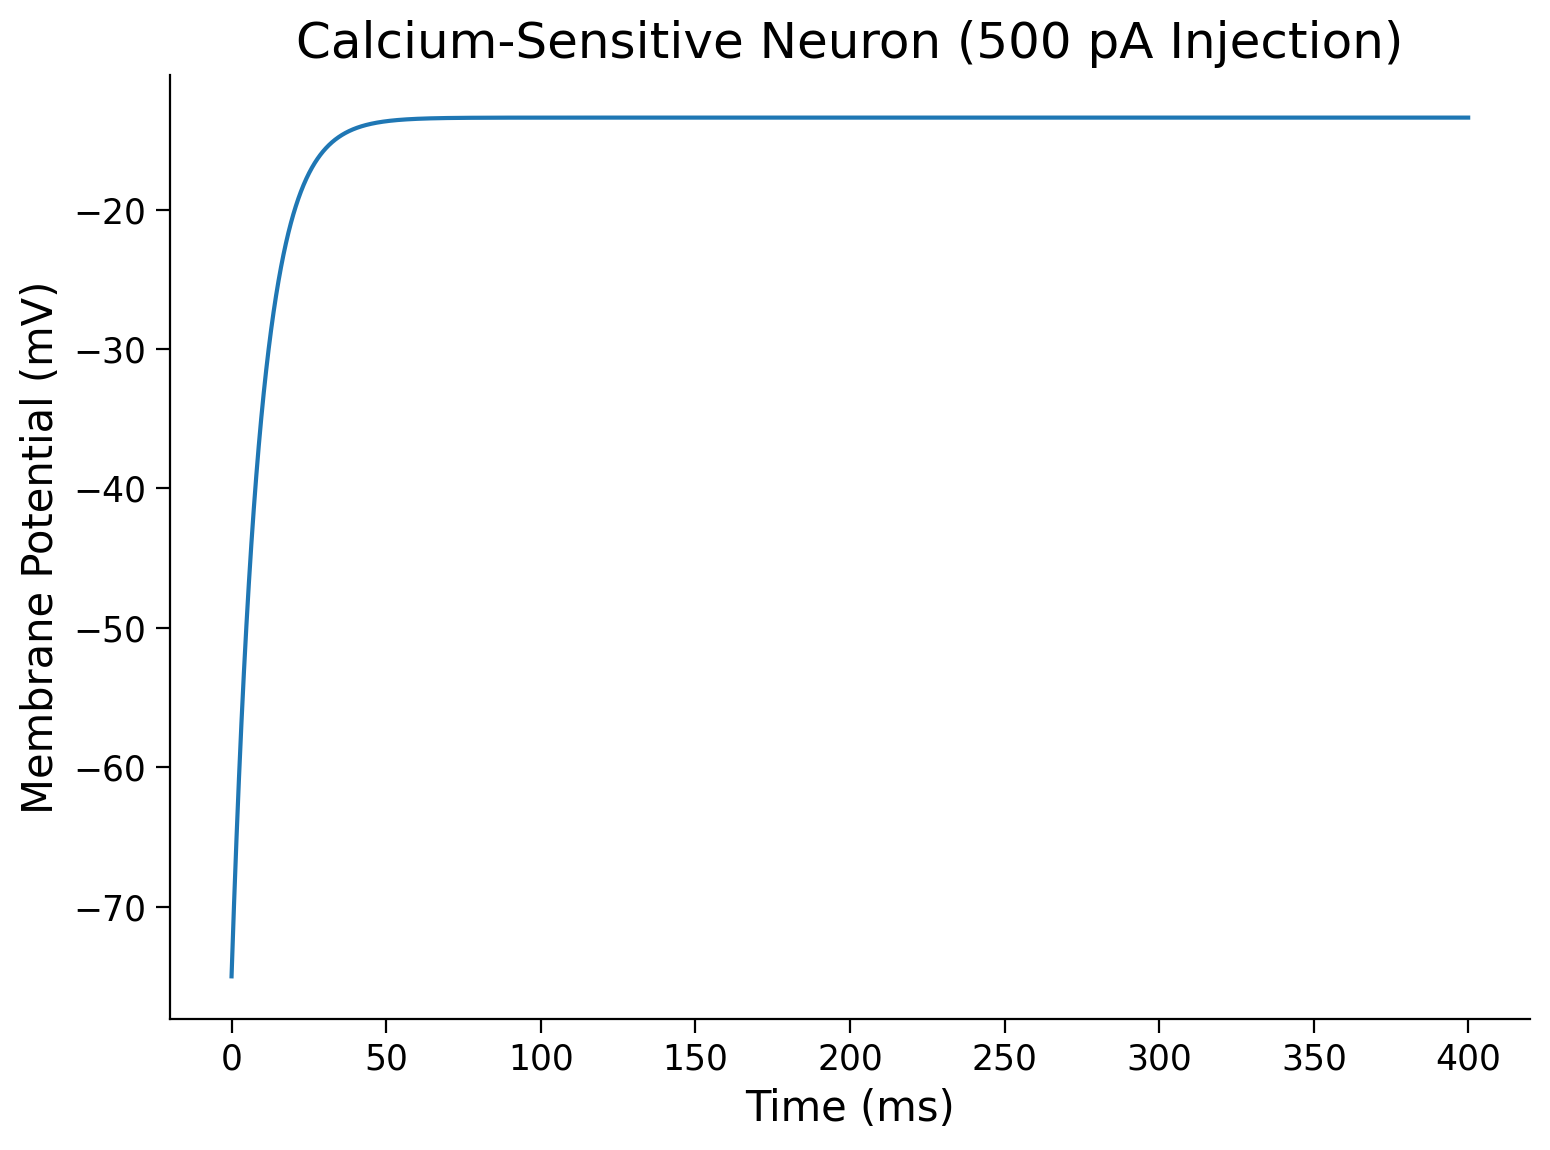

In [188]:
pars = default_pars()
v, spikes = run_CaV_model(pars, Iinj=500) # Inject pA of current
plt.plot(pars['range_t'], v)
plt.title(f'Calcium-Sensitive Neuron (500 pA Injection)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.show()

Open Probability (m) is: 0.07142857142857142
Open Probability (m) is: 0.1875
Open Probability (m) is: 0.43478260869565216
Open Probability (m) is: 0.6976744186046512
Open Probability (m) is: 0.8849557522123894


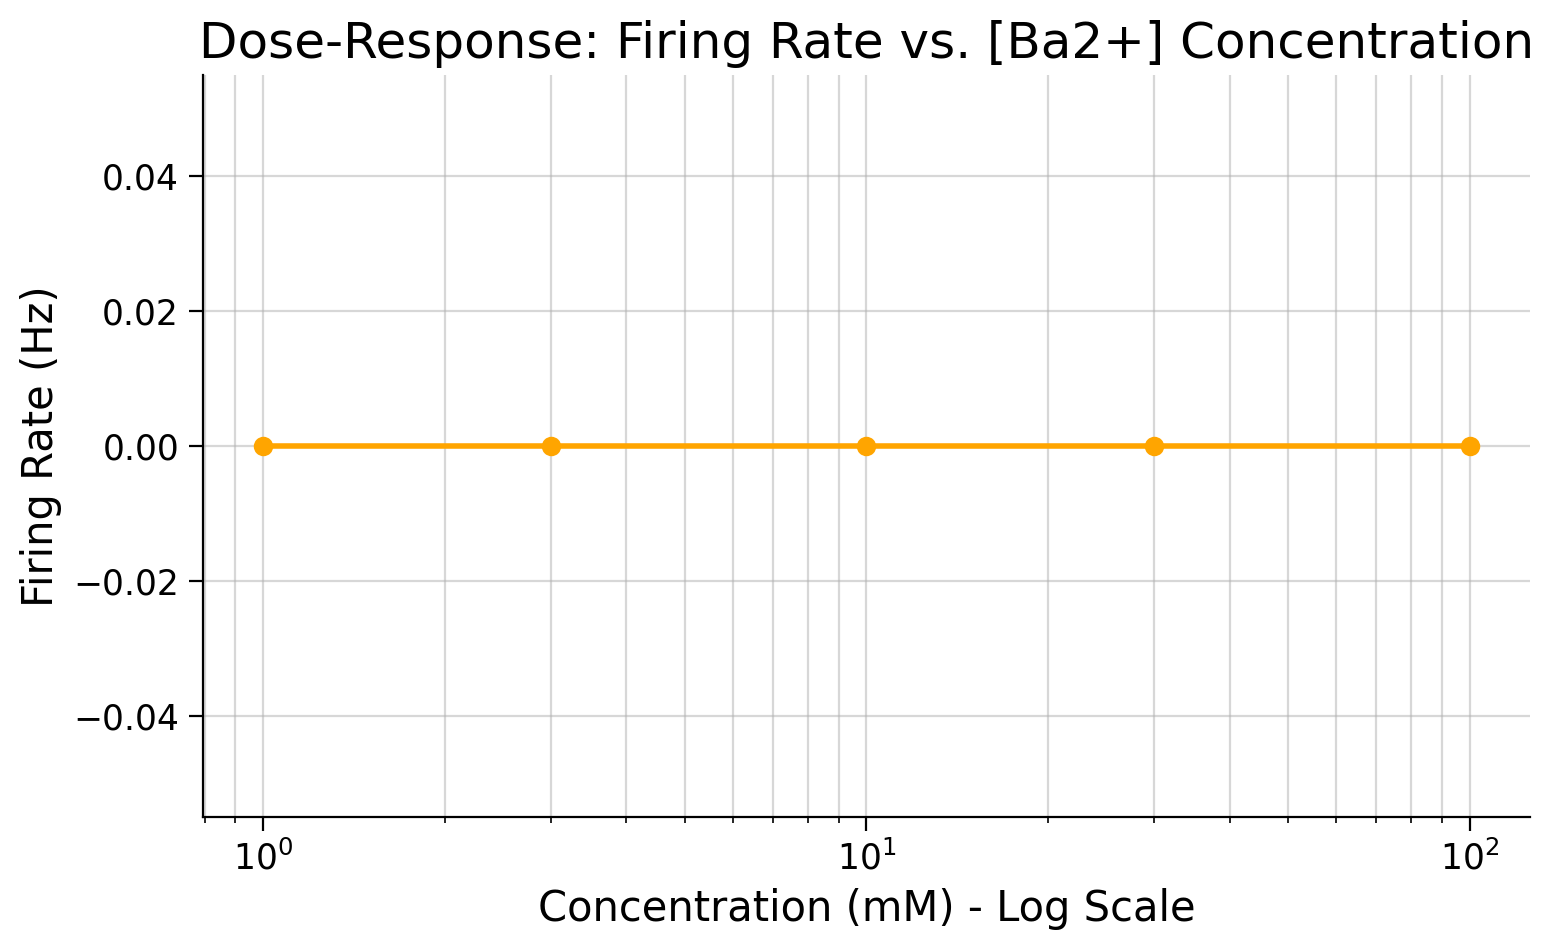

In [186]:
# Define a range of concentrations to test (from 1mM to 100mM)
concentrations = [1, 3, 10, 30, 100]
firing_rates = []

for c in concentrations:
    # We pass 'Conc' as an extra parameter
    # Note: You'll need to update your run_CaV_model to accept Conc or set it globally
    v_test, spikes_test = run_CaV_model(pars, Iinj=500, Conc=c)
    
    # Calculate firing rate (Hz): (Number of spikes / Total Time in ms) * 1000
    rate = (len(spikes_test) / pars['T']) * 1000
    firing_rates.append(rate)

# Plot the Result
plt.figure(figsize=(8, 5))
plt.semilogx(concentrations, firing_rates, 'o-', color='orange', linewidth=2)
plt.title('Dose-Response: Firing Rate vs. [Ba2+] Concentration')
plt.xlabel('Concentration (mM) - Log Scale')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

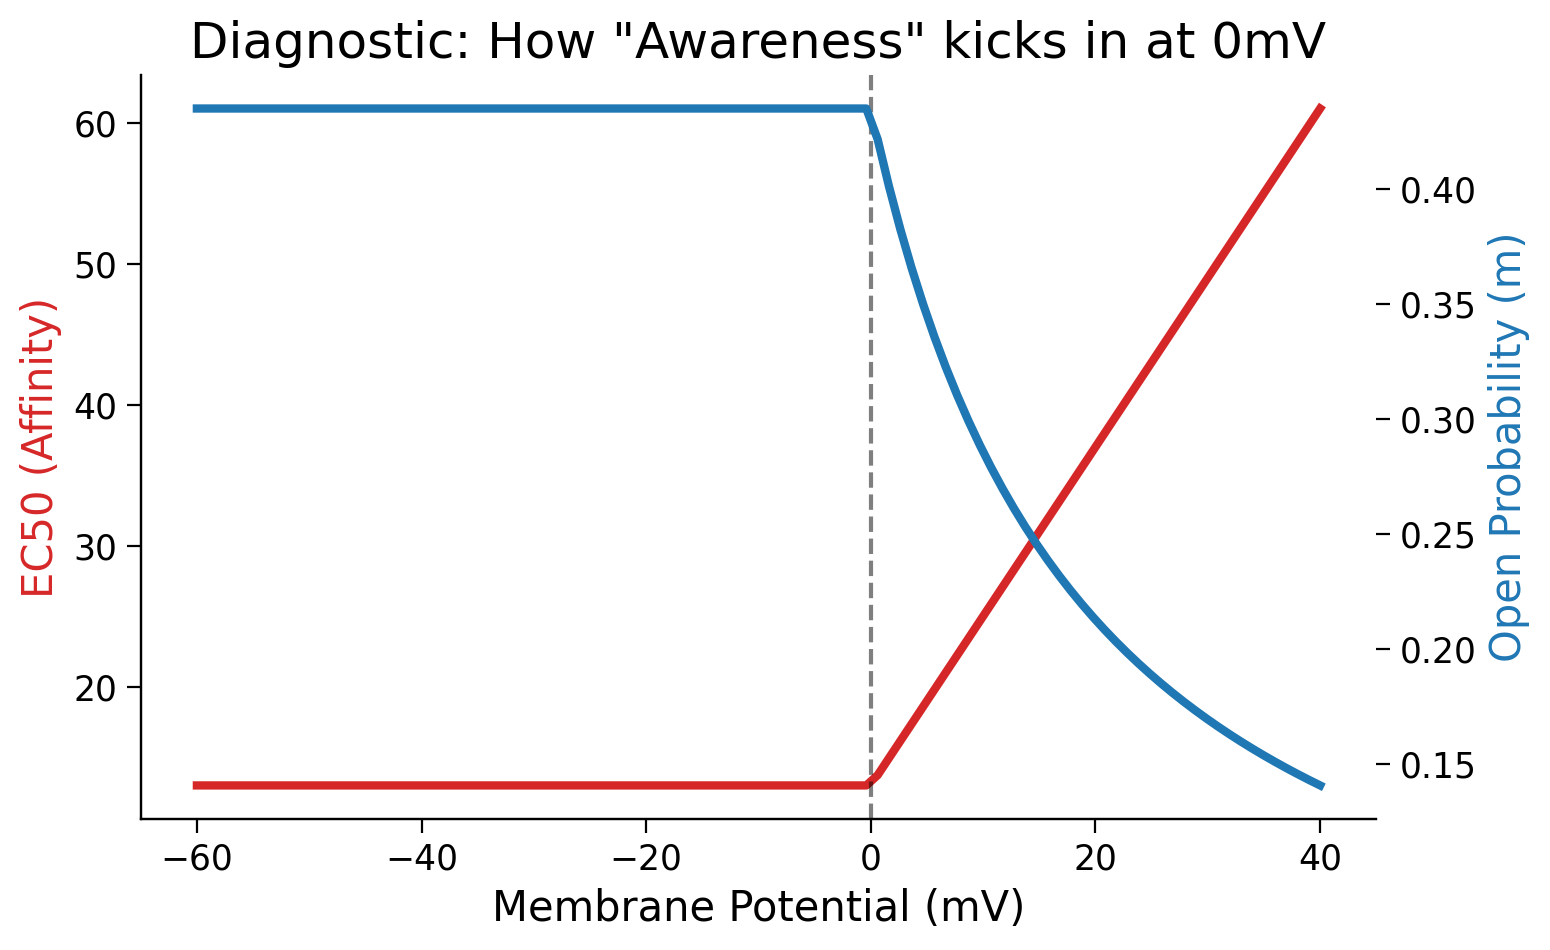

In [179]:
# 1. Setup a manual voltage climb from -60mV to +40mV
v_test = np.linspace(-60, 40, 100)
ec50_trace = []
m_trace = []

Conc = 10.0 # Our baseline concentration
EC50_rest = 13.0
k = 1.2

for v in v_test:
    # Applying the Buraei et al. (2015) logic
    if v <= 0:
        current_ec50 = EC50_rest
    else:
        current_ec50 = EC50_rest + k * v
    
    m = Conc / (Conc + current_ec50)
    ec50_trace.append(current_ec50)
    m_trace.append(m)

# 2. Plotting the "Awareness" Moment
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Membrane Potential (mV)')
ax1.set_ylabel('EC50 (Affinity)', color='tab:red')
ax1.plot(v_test, ec50_trace, color='tab:red', linewidth=3, label='EC50')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5) # The threshold of awareness

ax2 = ax1.twinx()
ax2.set_ylabel('Open Probability (m)', color='tab:blue')
ax2.plot(v_test, m_trace, color='tab:blue', linewidth=3, label='m')

plt.title('Diagnostic: How "Awareness" kicks in at 0mV')
plt.show()

In [180]:
# @title Helper Functions
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = 20    # spike threshold [mV]
  pars['V_reset'] = -65.  # reset potential [mV]
  pars['tau_m'] = 10.     # membrane time constant [ms]
  pars['g_L'] = 10.       # leak conductance [nS]
  pars['V_init'] = -75.   # initial potential [mV]
  pars['V_L'] = -75.      # leak reversal potential [mV]
  pars['tref'] = 2.0       # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 400. # Total duration of simulation [ms]
  pars['dt'] = .1  # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized
                                                         # time points [ms]
  return pars


def run_LIF(pars, Iinj):
  """
  Simulate the LIF dynamics with external input current

  Args:
    pars       : parameter dictionary
    Iinj       : input current [pA]. The injected current here can be a value or an array

  Returns:
    rec_spikes : spike times
    rec_v      : mebrane potential
  """

  # Set parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, V_L = pars['V_init'], pars['V_L']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size
  tref = pars['tref']

  # Initialize voltage and current
  v = np.zeros(Lt)
  v[0] = V_init
  Iinj = Iinj * np.ones(Lt)
  tr = 0.

  # simulate the LIF dynamics
  rec_spikes = []   # record spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    # calculate the increment of the membrane potential
    dv = (-(v[it] - V_L) + Iinj[it] / g_L) * (dt / tau_m)

    # update the membrane potential
    v[it + 1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes

Open Probability (m) is: 0.43478260869565216


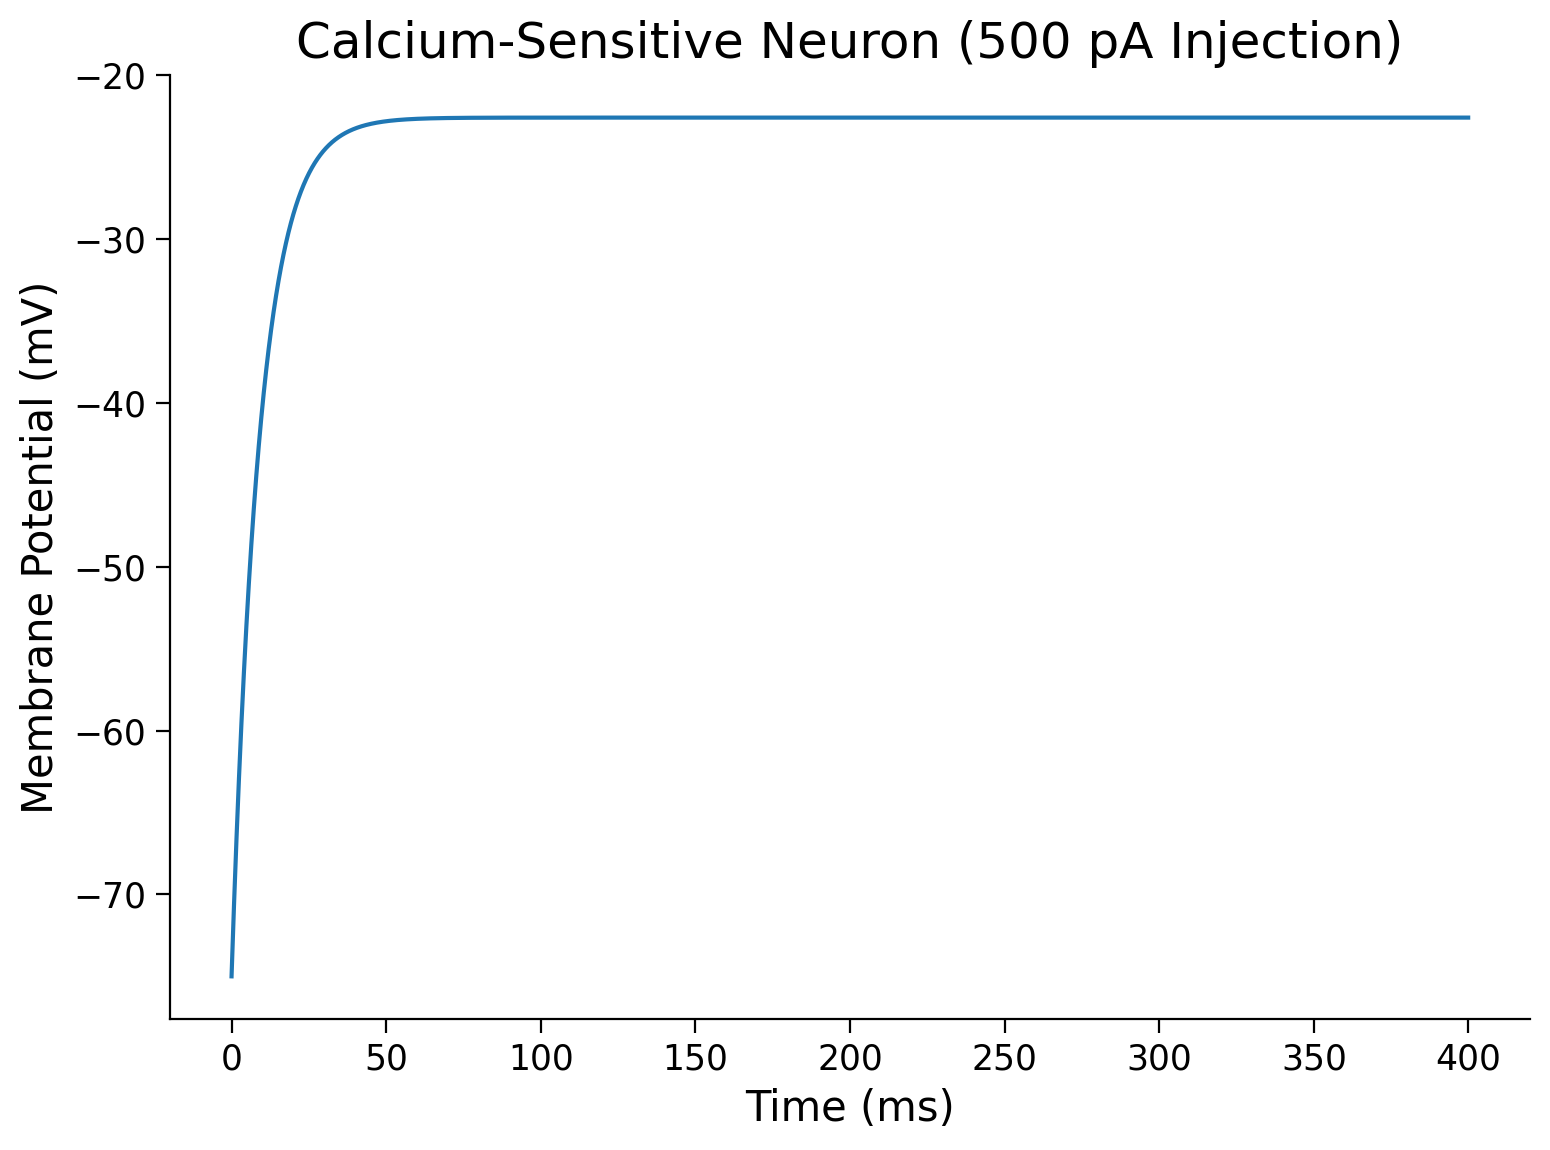

In [181]:
pars = default_pars()
v, spikes = run_CaV_model(pars, Iinj=400) # Inject pA of current
plt.plot(pars['range_t'], v)
plt.title(f'Calcium-Sensitive Neuron (500 pA Injection)')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential (mV)')
plt.show()

Open Probability (m) is: 0.07142857142857142
Open Probability (m) is: 0.1875
Open Probability (m) is: 0.43478260869565216
Open Probability (m) is: 0.6976744186046512
Open Probability (m) is: 0.8849557522123894


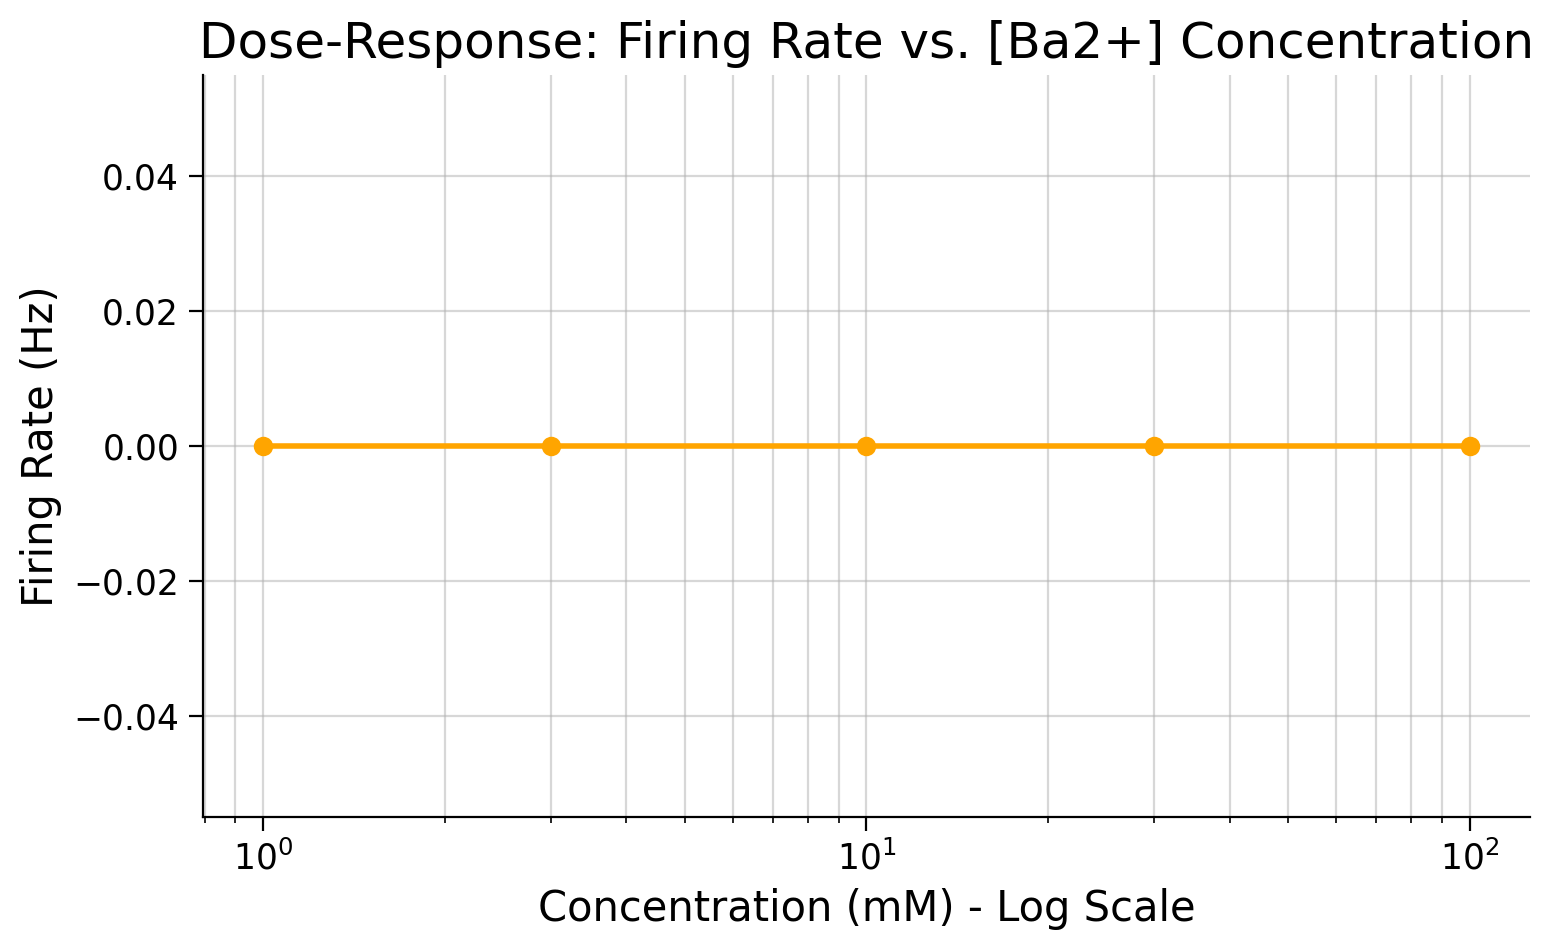

In [182]:
# Define a range of concentrations to test (from 1mM to 100mM)
concentrations = [1, 3, 10, 30, 100]
firing_rates = []

for c in concentrations:
    # We pass 'Conc' as an extra parameter
    # Note: You'll need to update your run_CaV_model to accept Conc or set it globally
    v_test, spikes_test = run_CaV_model(pars, Iinj=250, Conc=c)
    
    # Calculate firing rate (Hz): (Number of spikes / Total Time in ms) * 1000
    rate = (len(spikes_test) / pars['T']) * 1000
    firing_rates.append(rate)

# Plot the Result
plt.figure(figsize=(8, 5))
plt.semilogx(concentrations, firing_rates, 'o-', color='orange', linewidth=2)
plt.title('Dose-Response: Firing Rate vs. [Ba2+] Concentration')
plt.xlabel('Concentration (mM) - Log Scale')
plt.ylabel('Firing Rate (Hz)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

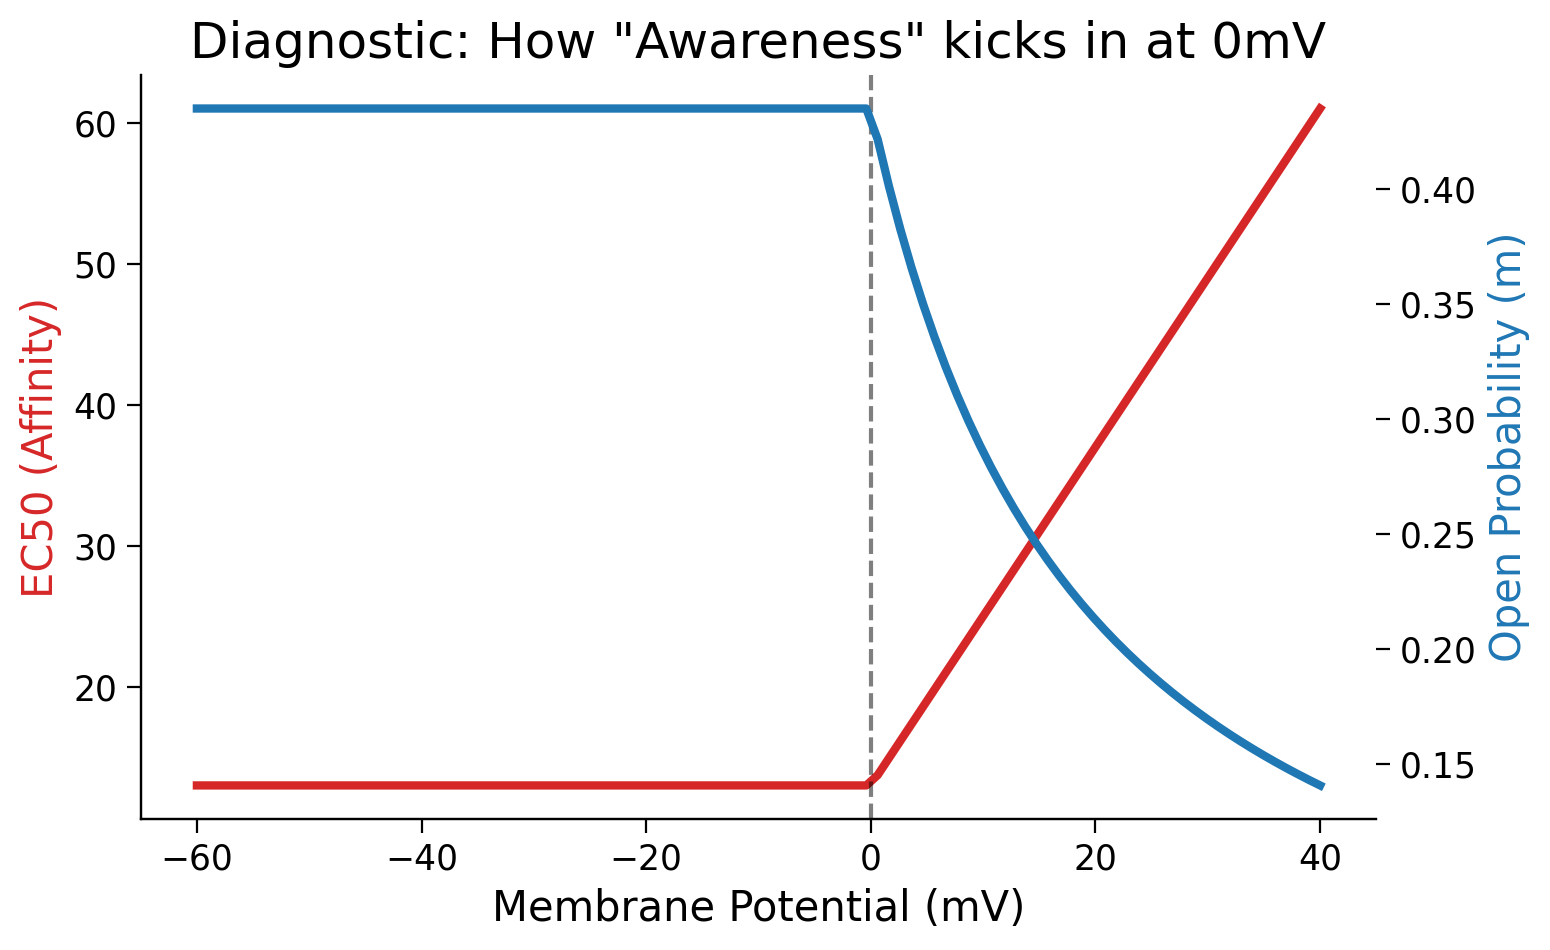

In [183]:
# 1. Setup a manual voltage climb from -60mV to +40mV
v_test = np.linspace(-60, 40, 100)
ec50_trace = []
m_trace = []

Conc = 10.0 # Our baseline concentration
EC50_rest = 13.0
k = 1.2

for v in v_test:
    # Applying the Buraei et al. (2015) logic
    if v <= 0:
        current_ec50 = EC50_rest
    else:
        current_ec50 = EC50_rest + k * v
    
    m = Conc / (Conc + current_ec50)
    ec50_trace.append(current_ec50)
    m_trace.append(m)

# 2. Plotting the "Awareness" Moment
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('Membrane Potential (mV)')
ax1.set_ylabel('EC50 (Affinity)', color='tab:red')
ax1.plot(v_test, ec50_trace, color='tab:red', linewidth=3, label='EC50')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5) # The threshold of awareness

ax2 = ax1.twinx()
ax2.set_ylabel('Open Probability (m)', color='tab:blue')
ax2.plot(v_test, m_trace, color='tab:blue', linewidth=3, label='m')

plt.title('Diagnostic: How "Awareness" kicks in at 0mV')
plt.show()